# Neural Network Win Probability Model

Train a small dense NN to predict win probability from chase state `(runs_needed, balls_remaining, wickets_fallen)`.

**Target**: smoothed empirical win probability per bin (from notebook 02) — we're fitting a smooth function to the historical data rather than a lookup table.

**Why this over the formula**: the formula assumes a fixed avg scoring rate and a symmetric sigmoid. The NN can learn the actual non-linear shape — e.g. that losing a wicket in over 18 matters much more than in over 5.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

torch.manual_seed(42)
np.random.seed(42)

IPL_DIR = r'C:\Users\hp\AppData\Local\Temp\cricket_data\ipl_all'
DATA    = '../data/raw/'

FIG_DIR = Path('../data/figures/03_nn_win_prob')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Step 1: Rebuild full IPL ball-state dataset
(Same as notebook 02 — rerun to keep this notebook self-contained)

In [2]:
def parse_chase_states(match_path):
    with open(match_path) as f:
        d = json.load(f)
    if len(d['innings']) < 2:
        return []
    outcome = d['info'].get('outcome', {})
    if 'winner' not in outcome:
        return []

    inn1, inn2 = d['innings'][0], d['innings'][1]
    chasing_team = inn2['team']
    chaser_won = int(outcome['winner'] == chasing_team)

    inn1_score = sum(b['runs']['total'] for ov in inn1['overs'] for b in ov['deliveries'])
    target = inn1_score + 1
    total_balls = sum(
        1 for ov in inn1['overs'] for b in ov['deliveries']
        if 'wides' not in b.get('extras', {}) and 'noballs' not in b.get('extras', {})
    )

    rows = []
    score, wickets, legal_ball = 0, 0, 0
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rows.append({
                    'runs_needed': target - score,
                    'balls_remaining': total_balls - legal_ball,
                    'wickets_fallen': wickets,
                    'total_balls': total_balls,
                    'chaser_won': chaser_won,
                })
    return rows


all_rows = []
for fname in os.listdir(IPL_DIR):
    if not fname.endswith('.json'):
        continue
    try:
        all_rows.extend(parse_chase_states(os.path.join(IPL_DIR, fname)))
    except Exception:
        pass

df = pd.DataFrame(all_rows)
print(f'Ball-states: {len(df):,}  |  Chaser win rate: {df["chaser_won"].mean():.3f}')

Ball-states: 128,511  |  Chaser win rate: 0.521


## Step 2: Build smoothed empirical target

Bin → compute win rate per bin → use as soft regression target instead of raw 0/1.
This lets the NN fit a smooth function rather than chase noisy binary labels.

Training rows (with valid target): 122,742


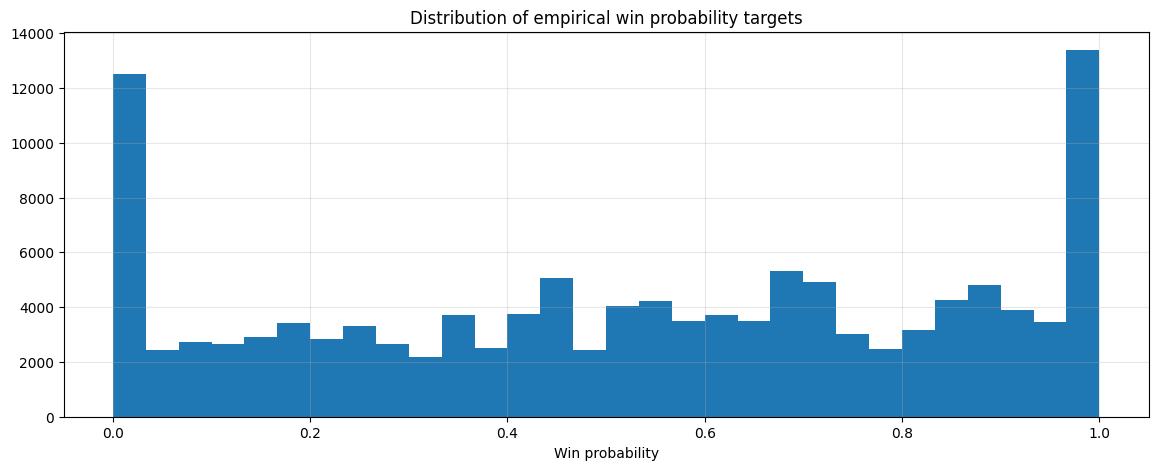

In [3]:
df['rn_bin'] = (df['runs_needed'] // 5) * 5
df['br_bin'] = (df['balls_remaining'] // 6) * 6
df['wk_bin'] = df['wickets_fallen'].clip(0, 9)

emp = (
    df.groupby(['rn_bin', 'br_bin', 'wk_bin'])
    .agg(win_rate=('chaser_won', 'mean'), n=('chaser_won', 'count'))
    .reset_index()
)
emp = emp[emp['n'] >= 10]

emp_lookup = {
    (row.rn_bin, row.br_bin, row.wk_bin): row.win_rate
    for row in emp.itertuples()
}

def get_target(rn, br, wk):
    key = (int((rn//5)*5), int((br//6)*6), int(min(wk, 9)))
    return emp_lookup.get(key, np.nan)

df['win_prob_target'] = df.apply(
    lambda r: get_target(r['runs_needed'], r['balls_remaining'], r['wickets_fallen']), axis=1
)

train_df = df.dropna(subset=['win_prob_target']).copy()
print(f'Training rows (with valid target): {len(train_df):,}')
train_df['win_prob_target'].hist(bins=30)
plt.title('Distribution of empirical win probability targets')
plt.xlabel('Win probability')
plt.show()

## Step 3: Features and normalisation

Raw features: `runs_needed`, `balls_remaining`, `wickets_fallen`  
Derived features: `rrr` (required run rate), `balls_fraction` (urgency), `wickets_fraction`

In [4]:
train_df = train_df.copy()
train_df['rrr']             = train_df['runs_needed'] / (train_df['balls_remaining'] + 1)
train_df['balls_fraction']  = train_df['balls_remaining'] / train_df['total_balls']
train_df['wickets_fraction'] = train_df['wickets_fallen'] / 10.0

FEATURE_COLS = ['runs_needed', 'balls_remaining', 'wickets_fallen',
                'rrr', 'balls_fraction', 'wickets_fraction']

X = train_df[FEATURE_COLS].values.astype(np.float32)
y = train_df['win_prob_target'].values.astype(np.float32)

# Normalise features (z-score)
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8
X_norm = (X - X_mean) / X_std

print('Feature means:', dict(zip(FEATURE_COLS, X_mean.round(2))))
print('Feature stds: ', dict(zip(FEATURE_COLS, X_std.round(2))))

Feature means: {'runs_needed': 94.85, 'balls_remaining': 62.66, 'wickets_fallen': 2.42, 'rrr': 1.73, 'balls_fraction': 0.53, 'wickets_fraction': 0.24}
Feature stds:  {'runs_needed': 50.44, 'balls_remaining': 33.28, 'wickets_fallen': 2.1, 'rrr': 1.88, 'balls_fraction': 0.28, 'wickets_fraction': 0.21}


## Step 4: Define the model

In [5]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = WinProbNet()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params}')

WinProbNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Total parameters: 3073


## Step 5: Train

Epoch  10/50 — train MSE: 0.00620  val MSE: 0.00536
Epoch  20/50 — train MSE: 0.00569  val MSE: 0.00488
Epoch  30/50 — train MSE: 0.00540  val MSE: 0.00482
Epoch  40/50 — train MSE: 0.00529  val MSE: 0.00453
Epoch  50/50 — train MSE: 0.00517  val MSE: 0.00445


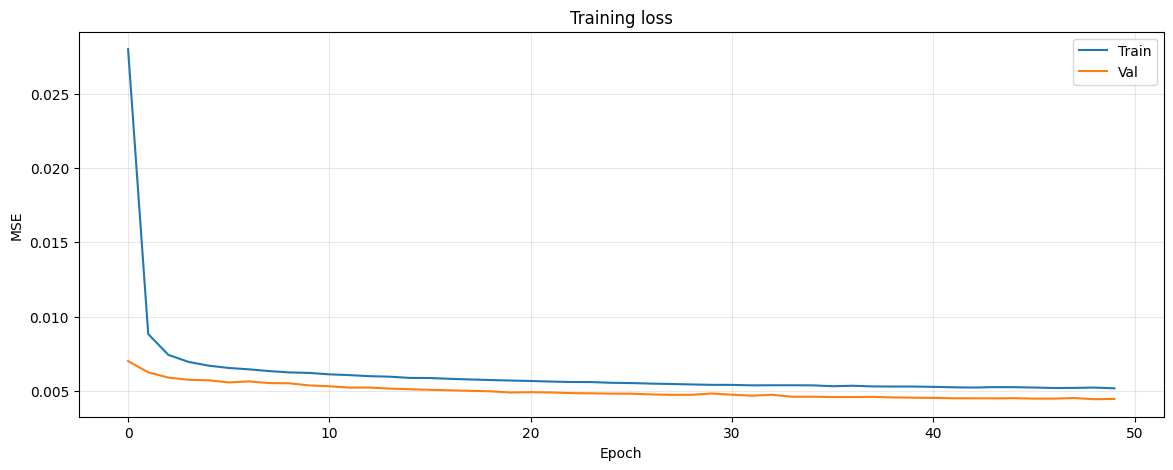

In [6]:
X_tensor = torch.tensor(X_norm)
y_tensor = torch.tensor(y)

dataset = TensorDataset(X_tensor, y_tensor)
n_val   = int(0.15 * len(dataset))
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()  # MSE against soft empirical targets

EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        val_loss = np.mean([loss_fn(model(xb), yb).item() for xb, yb in val_loader])
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} — train MSE: {train_losses[-1]:.5f}  val MSE: {val_losses[-1]:.5f}')

plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

## Step 6: Apply to our 4 matches and compare all three models

In [7]:
def nn_win_prob_batch(chase_df):
    """Run the NN on a chase DataFrame, return array of win probabilities."""
    feat = chase_df[['runs_needed', 'balls_remaining', 'wickets_fallen']].copy()
    feat['rrr']              = feat['runs_needed'] / (feat['balls_remaining'] + 1)
    feat['balls_fraction']   = feat['balls_remaining'] / 120  # normalise to full game
    feat['wickets_fraction'] = feat['wickets_fallen'] / 10.0
    X_raw = feat[FEATURE_COLS].values.astype(np.float32)
    X_n   = (X_raw - X_mean) / X_std
    with torch.no_grad():
        probs = model(torch.tensor(X_n)).numpy()
    return probs

def parse_innings(match_data, innings_idx):
    rows = []
    inn = match_data['innings'][innings_idx]
    cumulative, wickets, legal_ball = 0, 0, 0
    for ov in inn['overs']:
        for ball in ov['deliveries']:
            ext = list(ball.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            cumulative += ball['runs']['total']
            if 'wickets' in ball:
                wickets += len(ball['wickets'])
            if is_legal:
                legal_ball += 1
            rows.append({
                'legal_ball': legal_ball, 'score': cumulative,
                'wickets_fallen': wickets, 'is_legal': is_legal,
                'is_wicket': 'wickets' in ball,
            })
    return pd.DataFrame(rows)

AVG_RATE, SENSITIVITY = 1.667, 20

def empirical_win_prob(rn, br, wk):
    key = (int((rn//5)*5), int((br//6)*6), int(min(wk, 9)))
    if key in emp_lookup:
        return emp_lookup[key]
    for off in [1, -1, 2, -2]:
        k2 = (key[0], key[1], max(0, min(9, key[2]+off)))
        if k2 in emp_lookup:
            return emp_lookup[k2]
    return float(np.clip(1 - rn / (br * AVG_RATE + 1), 0.02, 0.98))

def build_chase(path):
    d = json.load(open(path))
    inn = [parse_innings(d, i) for i in range(len(d['innings']))]
    target = inn[0]['score'].iloc[-1] + 1
    total_balls = inn[0][inn[0]['is_legal']]['legal_ball'].max()
    df = inn[1][inn[1]['is_legal']].copy().reset_index(drop=True)
    df['target']          = target
    df['runs_needed']     = target - df['score']
    df['balls_remaining'] = total_balls - df['legal_ball']

    # Tuned formula
    wih = 10 - df['wickets_fallen']
    gap = df['balls_remaining'] * AVG_RATE * (wih/10)**0.5 - df['runs_needed']
    df['win_prob_formula'] = (1 / (1 + np.exp(-gap / SENSITIVITY))).clip(0.02, 0.98)

    # Empirical (smoothed)
    raw_emp = df.apply(
        lambda r: empirical_win_prob(r['runs_needed'], r['balls_remaining'], r['wickets_fallen']), axis=1
    ).values
    n = len(raw_emp)
    window = min(11, n if n % 2 == 1 else n - 1)
    df['win_prob_empirical'] = savgol_filter(raw_emp, window, 2).clip(0.02, 0.98) if window >= 3 else raw_emp

    # NN
    df['win_prob_nn'] = nn_win_prob_batch(df)

    return df, target


match_files = {
    'DC vs GT (HOT)':       'dc_vs_gt_2026-04-08.json',
    'IND vs PAK (HOT)':     'ind_vs_pak_2024-06-09.json',
    'RR vs MI (COLD)':      'rr_vs_mi_2026-04-07.json',
    'MI vs RR (COLD)':      'mi_vs_rr_2025-05-01.json',
}

results = {}
for label, fname in match_files.items():
    chase, target = build_chase(DATA + fname)
    results[label] = chase
    print(f'{label}: target={target}')

DC vs GT (HOT): target=211
IND vs PAK (HOT): target=120
RR vs MI (COLD): target=151
MI vs RR (COLD): target=218


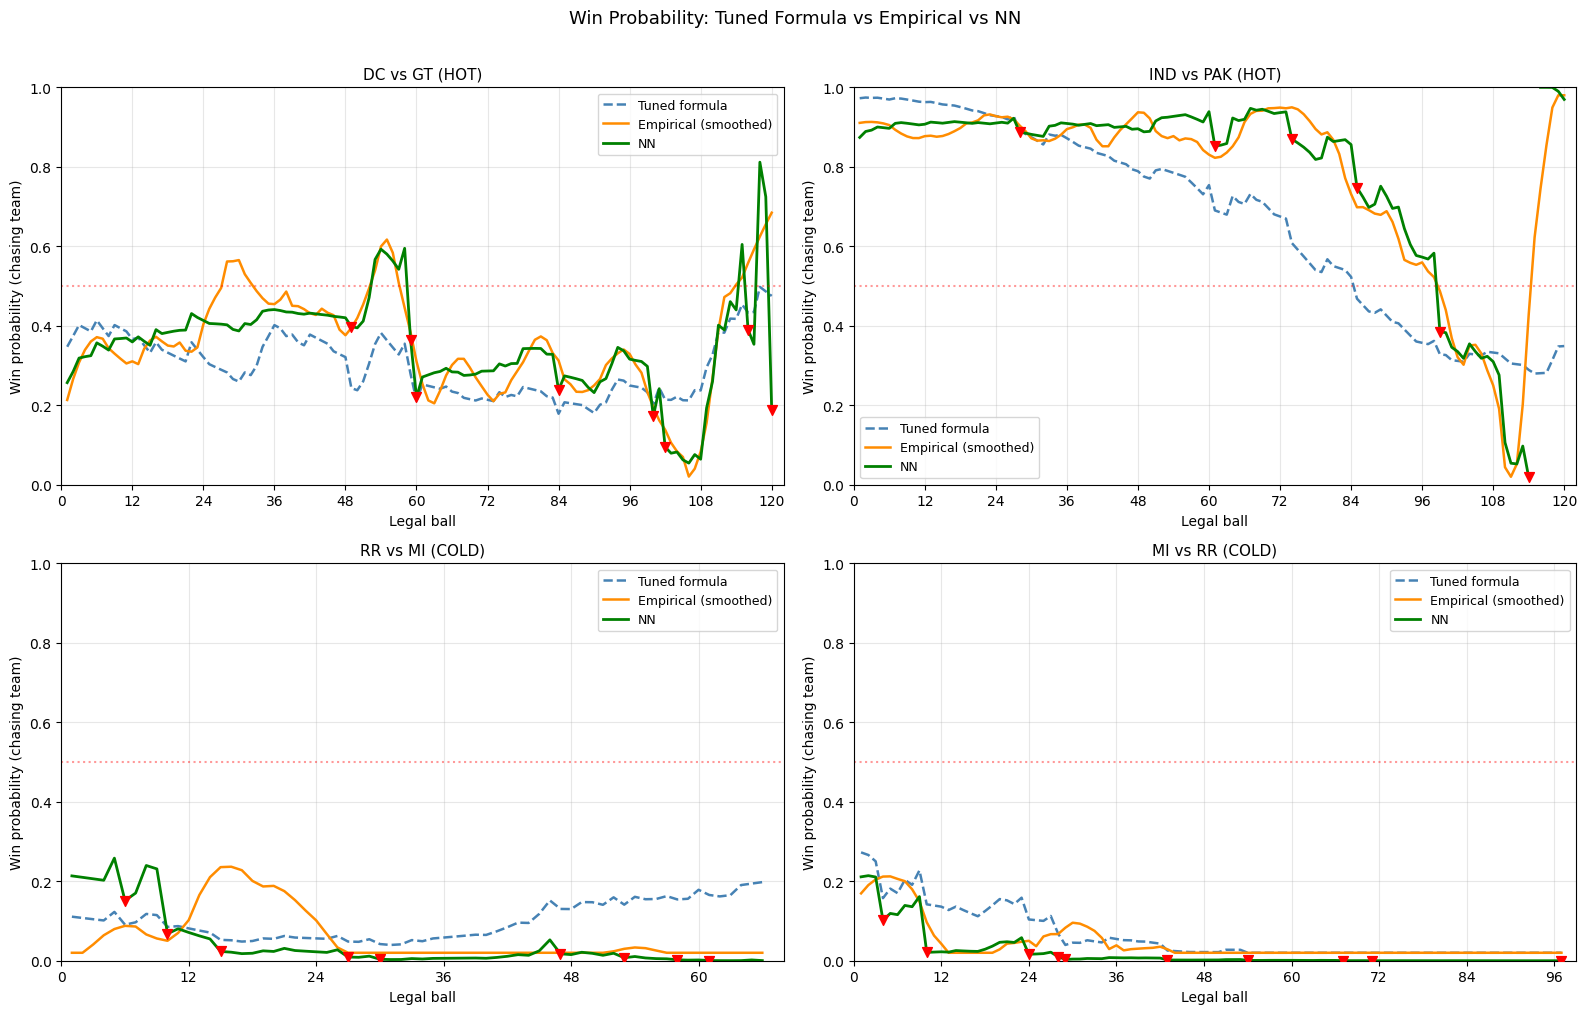

Match                      MAE formula     MAE NN
--------------------------------------------------
DC vs GT (HOT)                   0.093      0.046
IND vs PAK (HOT)                 0.148      0.040
RR vs MI (COLD)                  0.088      0.059
MI vs RR (COLD)                  0.025      0.027


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (label, chase) in zip(axes, results.items()):
    ax.plot(chase['legal_ball'], chase['win_prob_formula'],
            label='Tuned formula', color='steelblue', linewidth=1.8, linestyle='--')
    ax.plot(chase['legal_ball'], chase['win_prob_empirical'],
            label='Empirical (smoothed)', color='darkorange', linewidth=1.8)
    ax.plot(chase['legal_ball'], chase['win_prob_nn'],
            label='NN', color='green', linewidth=2)
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.4)
    wk = chase[chase['is_wicket']]
    ax.scatter(wk['legal_ball'], wk['win_prob_nn'], color='red', zorder=5, s=50, marker='v')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win probability (chasing team)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, chase['legal_ball'].max() + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=9)

plt.suptitle('Win Probability: Tuned Formula vs Empirical vs NN', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'win_prob_nn.png', dpi=150, bbox_inches='tight')
plt.show()

# MAE vs smoothed empirical
print(f"{'Match':<25} {'MAE formula':>12} {'MAE NN':>10}")
print('-' * 50)
for label, chase in results.items():
    mae_f  = (chase['win_prob_formula']   - chase['win_prob_empirical']).abs().mean()
    mae_nn = (chase['win_prob_nn'] - chase['win_prob_empirical']).abs().mean()
    print(f"{label:<25} {mae_f:>12.3f} {mae_nn:>10.3f}")

## Step 7: Save model artifacts for notebook 4

Notebook `04_model_interpretability.ipynb` expects:
- `../models/win_prob_nn.pt` (PyTorch checkpoint with model + normalisation stats)
- `../models/emp_lookup.pkl` (empirical lookup table)

In [9]:
from pathlib import Path
import pickle

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DIM = len(FEATURE_COLS)
HIDDEN_DIMS = [64, 32, 16]

ckpt = {
    'input_dim': INPUT_DIM,
    'hidden_dims': HIDDEN_DIMS,
    'model_state_dict': model.state_dict(),
    'feature_cols': FEATURE_COLS,
    'X_mean': X_mean,
    'X_std': X_std,
}

torch.save(ckpt, MODELS_DIR / 'win_prob_nn.pt')

with open(MODELS_DIR / 'emp_lookup.pkl', 'wb') as f:
    pickle.dump(emp_lookup, f)

print('Saved:', MODELS_DIR / 'win_prob_nn.pt')
print('Saved:', MODELS_DIR / 'emp_lookup.pkl')
print('Checkpoint keys:', list(ckpt.keys()))

Saved: ..\models\win_prob_nn.pt
Saved: ..\models\emp_lookup.pkl
Checkpoint keys: ['input_dim', 'hidden_dims', 'model_state_dict', 'feature_cols', 'X_mean', 'X_std']
